# Fit dual-process model to Remind data

Group level A and τ; subject-specific b, v3, and v4; trial-specific v1 (fixed-speed) and v2 (variable-speed). Trial-specific parameters predicted using mean activation in anatomical hippocampus and angular gyrus.

In [1]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import pymc as pm
import arviz as az
from devreact import figures
from devreact import task
from devreact import model
from IPython.display import display

data_dir = Path(os.environ['REMIND_RESULTS'])
data_file = data_dir / 'allsubj_alltest_data_2022.10.18.tsv'

model_name = 'neural-dual-v7A'

fig_dir = Path(os.environ['REMIND_FIGURES']) / 'model' / model_name
fig_dir.mkdir(parents=True, exist_ok=True)

%matplotlib inline
figures.set_style()
max_time = 8

## Load data

In [2]:
# load data and mean-centered neural activation in ROIs
signal_columns = ['b_dlpfc', 'b_pre', 'b_ang', 'B_IPS_SPL', 'b_hip', 'b_phc']
signal_names = ['vlpfc', 'prec', 'ang', 'lpc', 'hpc', 'phc']
raw = task.read_remind(data_file, signal_columns, signal_names)

# exclude trials with very fast response or no response
data = raw.query('response_time >= 0.3').dropna(subset=['response'])

In [3]:
# define coordinates and predictors
coords, subject_index, trial_type_index = model.get_data_coords(data)
data_mat = data[['response', 'response_time']].to_numpy()
n_steps = trial_type_index + 1

# subject information
_, oind = np.unique(data['subject'].to_numpy(), return_index=True)
age = data['age'].to_numpy()[oind]
age_centered = data['age_centered'].to_numpy()[oind]
age_code = data['age_bin'].cat.codes.to_numpy()[oind]

# neural signals, with excluded runs masked out
signal_data = {}
for signal in signal_names:
    x = data[signal].to_numpy()
    # x[np.isnan(x)] = 0
    signal_data[signal] = x

## Define probabilistic model

In [4]:
with pm.Model(coords=coords) as graph:
    x = pm.Data('x', data_mat, dims=['trial', 'component'])
    n = pm.Data('n', n_steps, dims=['trial'])
    a = pm.Data('a', age_centered, dims=['subject'])
    
    sind = pm.Data('subject_index', subject_index, dims=['trial'])
    tind = pm.Data('trial_type_index', trial_type_index, dims=['trial'])
    
    # variables used in analysis
    pm.Data('age', age, dims=['subject'])
    pm.Data('age_bin_index', age_code, dims=['subject'])
    pm.Data('trial_types', [0, 1], dims=['trial_type'])
    
    s = 1
    τ = pm.TruncatedNormal("τ", lower=0, upper=1, mu=0.5, sigma=0.5)
    A = model.age_var(
        'A', a, coef_mu=[1, 0], coef_sigma=[0.25, 0.05], beta=0.25, log=True
    )
    b = model.age_var(
        'b', a, coef_mu=[2, 0], coef_sigma=[0.5, 0.1], beta=0.5, log=True
    )
    
    # settings to link age and neural signals to parameters
    subject_mu = [3, 0]
    subject_sigma = [1, 0.1]
    subject_beta = 0.5
    signal_mu = [0, 0]
    signal_sigma = [1, 0.1]
    signal_beta = 1
    
    # drift rates varying with age and neural signals
    v1 = model.age_var('v1', a, subject_mu, subject_sigma, subject_beta)
    v2 = model.age_var('v2', a, subject_mu, subject_sigma, subject_beta)
    
    # neural signal coefficients
    neural_vars = ['v1', 'v2']
    pred, coef = model.age_signal_var(
        neural_vars, a, signal_mu, signal_sigma, signal_beta, signal_data, signal_names
    )
    
    r = pm.TruncatedNormal("r", lower=0, upper=1, mu=0.5, sigma=0.5)
    
    # drift rates that vary with age
    v3 = model.age_var('v3', a, subject_mu, subject_sigma, subject_beta)
    v4 = model.age_var('v4', a, subject_mu, subject_sigma, subject_beta)
    
    v1_trial = pm.Deterministic(
        'v1_trial',
        v1[sind] +
        pred['hpc'] * coef['hpc']['v1'][sind] + 
        pred['phc'] * coef['phc']['v1'][sind] +
        pred['prec'] * coef['prec']['v1'][sind] +
        pred['ang'] * coef['ang']['v1'][sind] +
        pred['lpc'] * coef['lpc']['v1'][sind] +
        pred['vlpfc'] * coef['vlpfc']['v1'][sind]
    )
    v2_trial = pm.Deterministic(
        'v2_trial',
        v2[sind] +
        pred['hpc'] * coef['hpc']['v2'][sind] + 
        pred['phc'] * coef['phc']['v2'][sind] +
        pred['prec'] * coef['prec']['v2'][sind] +
        pred['ang'] * coef['ang']['v2'][sind] +
        pred['lpc'] * coef['lpc']['v2'][sind] +
        pred['vlpfc'] * coef['vlpfc']['v2'][sind]
    )
    response = pm.DensityDist(
        'response',
        n,
        s,
        τ,
        A[sind],
        b[sind],
        v1_trial,
        v2_trial,
        r,
        v3[sind],
        v4[sind],
        logp=model.logp_dual,
        random=model.random_dual,
        observed=x,
        dims=['trial', 'component'],
    )

In [5]:
# model-specific parameter settings
age_vars = ['A', 'b', 'v1', 'v2', 'v3', 'v4']
group_vars = ['τ', 'r']
params_vars = ['τ', 'A', 'b', 'v1', 'v2', 'r', 'v3', 'v4']

subject_vars = ['b0', 'b1', 'σ']
coef_vars = [f'b{i}' for i in range(len(signal_mu))]
trial_vars = coef_vars + ['σ']

In [6]:
# some useful parameter groups
neural_params_vars = [f'{n}_{s}' for n in neural_vars for s in signal_names]
subject_meta_vars = [f'{p}_{m}' for p in age_vars for m in subject_vars]
trial_meta_vars = [
    f'{p}_{s}_{m}' for p in neural_vars for s in signal_names for m in trial_vars
]
scalar_vars = group_vars + subject_meta_vars + trial_meta_vars

In [7]:
graph.basic_RVs

[τ ~ TruncatedNormal(0.5, 0.5, 0, 1),
 A_b0 ~ Normal(1, 0.25),
 A_b1 ~ Normal(0, 0.05),
 A_σ ~ HalfCauchy(0.25),
 A_c ~ Normal(0, 1),
 b_b0 ~ Normal(2, 0.5),
 b_b1 ~ Normal(0, 0.1),
 b_σ ~ HalfCauchy(0.5),
 b_c ~ Normal(0, 1),
 v1_b0 ~ Normal(3, 1),
 v1_b1 ~ Normal(0, 0.1),
 v1_σ ~ HalfCauchy(0.5),
 v1_c ~ Normal(0, 1),
 v2_b0 ~ Normal(3, 1),
 v2_b1 ~ Normal(0, 0.1),
 v2_σ ~ HalfCauchy(0.5),
 v2_c ~ Normal(0, 1),
 vlpfc_unobs ~ Normal(0, 1),
 v1_vlpfc_b0 ~ Normal(0, 1),
 v1_vlpfc_b1 ~ Normal(0, 0.1),
 v1_vlpfc_σ ~ HalfCauchy(1),
 v1_vlpfc_c ~ Normal(0, 1),
 v2_vlpfc_b0 ~ Normal(0, 1),
 v2_vlpfc_b1 ~ Normal(0, 0.1),
 v2_vlpfc_σ ~ HalfCauchy(1),
 v2_vlpfc_c ~ Normal(0, 1),
 prec_unobs ~ Normal(0, 1),
 v1_prec_b0 ~ Normal(0, 1),
 v1_prec_b1 ~ Normal(0, 0.1),
 v1_prec_σ ~ HalfCauchy(1),
 v1_prec_c ~ Normal(0, 1),
 v2_prec_b0 ~ Normal(0, 1),
 v2_prec_b1 ~ Normal(0, 0.1),
 v2_prec_σ ~ HalfCauchy(1),
 v2_prec_c ~ Normal(0, 1),
 ang_unobs ~ Normal(0, 1),
 v1_ang_b0 ~ Normal(0, 1),
 v1_ang_b1 ~

In [8]:
graph.point_logps()

{'τ': np.float64(-1.23),
 'A_b0': np.float64(0.47),
 'A_b1': np.float64(2.08),
 'A_σ': np.float64(-1.14),
 'A_c': np.float64(-68.0),
 'b_b0': np.float64(-0.23),
 'b_b1': np.float64(1.38),
 'b_σ': np.float64(-1.14),
 'b_c': np.float64(-68.0),
 'v1_b0': np.float64(-0.92),
 'v1_b1': np.float64(1.38),
 'v1_σ': np.float64(-1.14),
 'v1_c': np.float64(-68.0),
 'v2_b0': np.float64(-0.92),
 'v2_b1': np.float64(1.38),
 'v2_σ': np.float64(-1.14),
 'v2_c': np.float64(-68.0),
 'vlpfc_unobs': np.float64(-608.34),
 'v1_vlpfc_b0': np.float64(-0.92),
 'v1_vlpfc_b1': np.float64(1.38),
 'v1_vlpfc_σ': np.float64(-1.14),
 'v1_vlpfc_c': np.float64(-68.0),
 'v2_vlpfc_b0': np.float64(-0.92),
 'v2_vlpfc_b1': np.float64(1.38),
 'v2_vlpfc_σ': np.float64(-1.14),
 'v2_vlpfc_c': np.float64(-68.0),
 'prec_unobs': np.float64(-608.34),
 'v1_prec_b0': np.float64(-0.92),
 'v1_prec_b1': np.float64(1.38),
 'v1_prec_σ': np.float64(-1.14),
 'v1_prec_c': np.float64(-68.0),
 'v2_prec_b0': np.float64(-0.92),
 'v2_prec_b1': np.

## Prior predictive samples

Sampling: [A_b0, A_b1, A_c, A_σ, ang_unobs, b_b0, b_b1, b_c, b_σ, hpc_unobs, lpc_unobs, phc_unobs, prec_unobs, r, response, v1_ang_b0, v1_ang_b1, v1_ang_c, v1_ang_σ, v1_b0, v1_b1, v1_c, v1_hpc_b0, v1_hpc_b1, v1_hpc_c, v1_hpc_σ, v1_lpc_b0, v1_lpc_b1, v1_lpc_c, v1_lpc_σ, v1_phc_b0, v1_phc_b1, v1_phc_c, v1_phc_σ, v1_prec_b0, v1_prec_b1, v1_prec_c, v1_prec_σ, v1_vlpfc_b0, v1_vlpfc_b1, v1_vlpfc_c, v1_vlpfc_σ, v1_σ, v2_ang_b0, v2_ang_b1, v2_ang_c, v2_ang_σ, v2_b0, v2_b1, v2_c, v2_hpc_b0, v2_hpc_b1, v2_hpc_c, v2_hpc_σ, v2_lpc_b0, v2_lpc_b1, v2_lpc_c, v2_lpc_σ, v2_phc_b0, v2_phc_b1, v2_phc_c, v2_phc_σ, v2_prec_b0, v2_prec_b1, v2_prec_c, v2_prec_σ, v2_vlpfc_b0, v2_vlpfc_b1, v2_vlpfc_c, v2_vlpfc_σ, v2_σ, v3_b0, v3_b1, v3_c, v3_σ, v4_b0, v4_b1, v4_c, v4_σ, vlpfc_unobs, τ]


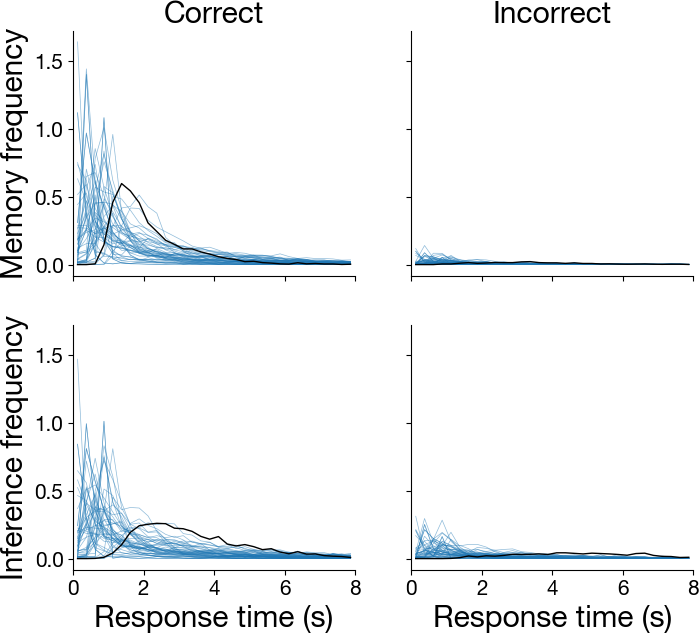

In [9]:
with graph:
    pp = pm.sample_prior_predictive()
fig, ax = figures.plot_predictive(pp, group='prior', max_time=max_time)

## Sample posterior distribution

In [ ]:
with graph:
    trace = pm.sample(
        init="jitter+adapt_diag_grad", tune=2000, draws=10000, target_accept=0.9
    )

Initializing NUTS using jitter+adapt_diag_grad...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [τ, A_b0, A_b1, A_σ, A_c, b_b0, b_b1, b_σ, b_c, v1_b0, v1_b1, v1_σ, v1_c, v2_b0, v2_b1, v2_σ, v2_c, vlpfc_unobs, v1_vlpfc_b0, v1_vlpfc_b1, v1_vlpfc_σ, v1_vlpfc_c, v2_vlpfc_b0, v2_vlpfc_b1, v2_vlpfc_σ, v2_vlpfc_c, prec_unobs, v1_prec_b0, v1_prec_b1, v1_prec_σ, v1_prec_c, v2_prec_b0, v2_prec_b1, v2_prec_σ, v2_prec_c, ang_unobs, v1_ang_b0, v1_ang_b1, v1_ang_σ, v1_ang_c, v2_ang_b0, v2_ang_b1, v2_ang_σ, v2_ang_c, lpc_unobs, v1_lpc_b0, v1_lpc_b1, v1_lpc_σ, v1_lpc_c, v2_lpc_b0, v2_lpc_b1, v2_lpc_σ, v2_lpc_c, hpc_unobs, v1_hpc_b0, v1_hpc_b1, v1_hpc_σ, v1_hpc_c, v2_hpc_b0, v2_hpc_b1, v2_hpc_σ, v2_hpc_c, phc_unobs, v1_phc_b0, v1_phc_b1, v1_phc_σ, v1_phc_c, v2_phc_b0, v2_phc_b1, v2_phc_σ, v2_phc_c, r, v3_b0, v3_b1, v3_σ, v3_c, v4_b0, v4_b1, v4_σ, v4_c]


Output()

Sampling 4 chains for 2_000 tune and 10_000 draw iterations (8_000 + 40_000 draws total) took 7898 seconds.


In [ ]:
trace_file = fig_dir / 'trace.nc'
trace_file.unlink(missing_ok=True)
trace.to_netcdf(trace_file, compress=False);

In [ ]:
ess = az.ess(trace)
ess_series = pd.Series({k: v.values for k, v in ess.min().variables.items()})
float(ess_series.min())

In [ ]:
rhat = az.rhat(trace)
rhat_series = pd.Series({k: v.values for k, v in rhat.max().variables.items()})
float(rhat_series.max())

In [ ]:
az.rcParams['plot.max_subplots'] = 10000
with mpl.rc_context({'figure.constrained_layout.use': True}):
    az.plot_trace(trace, subject_meta_vars);

In [ ]:
with mpl.rc_context({'figure.constrained_layout.use': True}):
    az.plot_trace(trace, trial_meta_vars);

In [ ]:
with mpl.rc_context({'figure.constrained_layout.use': True}):
    az.plot_trace(trace, params_vars);

In [ ]:
az.plot_pair(
    trace,
    kind='kde',
    var_names=scalar_vars,
    figsize=(len(scalar_vars), len(scalar_vars)),
);

In [ ]:
g = figures.plot_age_params(trace, age_vars)
figures.savefig(g, fig_dir / 'subject_param.pdf')

In [ ]:
param_name = 'v1'
neural_vars = [p for p in neural_params_vars if param_name in p]
g = figures.plot_age_params(trace, neural_vars)
figures.savefig(g, fig_dir / f'neural_param_{param_name}.pdf')

In [ ]:
fig, ax = figures.plot_signal_coef(trace, coef_vars, param_name, signal_names)
figures.savefig(fig, fig_dir / f'neural_param_coef_{param_name}.pdf')

In [ ]:
param_name = 'v2'
neural_vars = [p for p in neural_params_vars if param_name in p]
g = figures.plot_age_params(trace, neural_vars)
figures.savefig(g, fig_dir / f'neural_param_{param_name}.pdf')

In [ ]:
fig, ax = figures.plot_signal_coef(trace, coef_vars, param_name, signal_names)
figures.savefig(fig, fig_dir / f'neural_param_coef_{param_name}.pdf')

## Examine posterior predictive samples

In [ ]:
with graph:
    pp = pm.sample_posterior_predictive(trace)
pp_file = fig_dir / 'posterior_predictive.nc'
pp_file.unlink(missing_ok=True)
pp.to_netcdf(pp_file, compress=False);

In [ ]:
fig, ax = figures.plot_predictive(pp, group='posterior', max_time=max_time)

In [ ]:
fig, ax = figures.plot_predictive(
    pp, 
    group='posterior', 
    max_time=max_time, 
    row='accuracy', 
    col='age', 
    trial_type='direct',
)
figures.savefig(fig, fig_dir / 'predictive_rt_dist_direct.pdf')

In [ ]:
fig, ax = figures.plot_predictive(
    pp, 
    group='posterior', 
    max_time=max_time, 
    row='accuracy', 
    col='age', 
    trial_type='inference',
)
figures.savefig(fig, fig_dir / 'predictive_rt_dist_inference.pdf')

In [ ]:
g = figures.plot_predictive_acc(pp)
figures.savefig(g, fig_dir / 'predictive_accuracy.pdf')

In [ ]:
g = figures.plot_predictive_rt(pp, max_time=max_time)
figures.savefig(g, fig_dir / 'predictive_rt.pdf')

In [ ]:
%load_ext watermark
%watermark -v -iv